### OpenAI Whisper -> CNN -> Transformer -> Fully Connected -> Output

Goal is to try and replicate the architecture of OpenAI Whisper using a CNN and Transformer. Reference off the Automatic Speech Disfluency Detection Using wav2vec2.0 for Different Languages with Variable Lengths paper. 

In [1]:
import pandas as pd
import torch
import librosa
import os
from transformers import WhisperFeatureExtractor, WhisperModel
from tqdm.notebook import tqdm # visualization
import numpy as np 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader # for training
from sklearn.utils.class_weight import compute_class_weight # class weights
from sklearn.model_selection import train_test_split # split data
from sklearn.preprocessing import LabelEncoder #transform labels
import matplotlib.pyplot as plt # visualization
import seaborn as sns # visualization
from sklearn.metrics import confusion_matrix, classification_report # visualization
import copy # copy and save model 
import math
import gc

In [ ]:
df = pd.read_csv('../Training/SEP-28k-Extended_clips.csv')

disfluency_cols = ['Prolongation', 'Block', 'SoundRep', 'WordRep', 'Interjection']

absolute_labels_df = df[df[disfluency_cols].eq(2).any(axis=1)].copy()
# file path map
absolute_labels_df['audio_path'] = (
    'SEP-28k_CLIP/' + 
    absolute_labels_df['Show'] + '/' + 
    absolute_labels_df['EpId'].astype(str) + '/' + 
    absolute_labels_df['Show'] + '_' + 
    absolute_labels_df['EpId'].astype(str) + '_' + 
    absolute_labels_df['ClipId'].astype(str) + '.wav'
)

# target labels greater than 2
def get_label_info(row):
    for col in disfluency_cols:
        if row[col] >= 2:
            return pd.Series([col, row[col]])
    return pd.Series([None, 0])

# Create columns for the label and how many people voted for it
df[['target_label', 'vote_count']] = df.apply(get_label_info, axis=1)

# Filter Majority Agreement (>= 2 votes)
full_pool = df[df['target_label'].notna()].copy()


# We want to see the total available clips (3s + 2s) for each class
class_totals = full_pool['target_label'].value_counts()
target_size = class_totals.min() # This is the limit of the rarest class (3s+2s combined)

print(f"The rarest class has {target_size} total clips (3s + 2s).")
print(f"Targeting {target_size} clips per class for a total of {target_size * 5} rows.\n")


balanced_list = []

for label in disfluency_cols:
    # Separate the 3s and 2s for this class
    class_3s = full_pool[(full_pool['target_label'] == label) & (full_pool['vote_count'] == 3)]
    class_2s = full_pool[(full_pool['target_label'] == label) & (full_pool['vote_count'] == 2)]
    
    # Check if we have enough 3s to fill the target
    if len(class_3s) >= target_size:
        # If we have too many 3s, just take the best ones (3s)
        balanced_list.append(class_3s.sample(n=target_size, random_state=42))
    else:
        # If we don't have enough 3s, take ALL of them and fill the rest with 2s
        num_2s_needed = target_size - len(class_3s)
        sampled_2s = class_2s.sample(n=num_2s_needed, random_state=42)
        balanced_list.append(pd.concat([class_3s, sampled_2s]))

# Combine everything back together
absolute_labels_df = pd.concat(balanced_list).sample(frac=1, random_state=42) # Shuffle

# 5. Pathing (Keep your existing path logic)
absolute_labels_df['EpId_clean'] = absolute_labels_df['EpId'].astype(float).astype(int).astype(str)
absolute_labels_df['ClipId_clean'] = absolute_labels_df['ClipId'].astype(float).astype(int).astype(str)
absolute_labels_df['audio_path'] = (
    'SEP-28k_CLIP/' + absolute_labels_df['Show'] + '/' + absolute_labels_df['EpId_clean'] + '/' + 
    absolute_labels_df['Show'] + '_' + absolute_labels_df['EpId_clean'] + '_' + absolute_labels_df['ClipId_clean'] + '.wav'
)

print(f"Original 3-vote only size: 6,767")
print(f"New Hybrid Balanced size: {len(absolute_labels_df)}")
print("\nFinal Class Distribution (Should be identical):")
print(absolute_labels_df['target_label'].value_counts())

The rarest class has 1757 total clips (3s + 2s).
Targeting 1757 clips per class for a total of 8785 rows.

Original 3-vote only size: 6,767
New Hybrid Balanced size: 8785

Final Class Distribution (Should be identical):
target_label
Prolongation    1757
WordRep         1757
SoundRep        1757
Interjection    1757
Block           1757
Name: count, dtype: int64


In [3]:
df = absolute_labels_df.copy() 

# clean the IDs ex: '0.0' become '0'
df['EpId_clean'] = df['EpId'].astype(float).astype(int).astype(str)
df['ClipId_clean'] = df['ClipId'].astype(float).astype(int).astype(str)

# file path (../SEP-28k_CLIP) 
df['audio_path'] = (
    "../SEP-28k_CLIP/" + 
    df['Show'].astype(str) + "/" + 
    df['EpId_clean'] + "/" + 
    df['Show'].astype(str) + "_" + 
    df['EpId_clean'] + "_" + 
    df['ClipId_clean'] + ".wav"
)

# check for file path
test_path = df['audio_path'].iloc[0]
print(f"🔍 Checking first file at: {os.path.abspath(test_path)}")
if not os.path.exists(test_path):
    print("❌ ERROR: File STILL not found! Please stop and double-check your folder structure.")
else:
    print("✅ File found! Pathing is correct.\n")

# Set up the Whisper Model
model_name = "openai/whisper-base"
feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
model = WhisperModel.from_pretrained(model_name)

# find Mac GPU, also allowed for NVIDIA GPU
if torch.backends.mps.is_available():
    device = "mps"
    print("Using Mac GPU (MPS) for acceleration!")
elif torch.cuda.is_available():
    device = "cuda"
    print("Using NVIDIA GPU (CUDA) for acceleration!")
else:
    device = "cpu"
    print("Using CPU. (No GPU detected)")

model.to(device)

def get_whisper_embedding_sequence(audio_path):
    if not os.path.exists(audio_path): return None
    try:
        # Load audio at 16k Hz
        speech_array, sampling_rate = librosa.load(audio_path, sr=16000)
        inputs = feature_extractor(speech_array, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)
        
        with torch.no_grad():
            encoder_outputs = model.encoder(input_features)
            
        # remove squeeze dimension
        embedding = encoder_outputs.last_hidden_state.squeeze(0).cpu().numpy()
        return embedding 
    except Exception as e:
        print(f"Error: {e}")
        return None

# Process the files
print(f"Processing audio files into sequences...")
all_embeddings = []
valid_indices = []

for idx, path in tqdm(enumerate(df['audio_path']), total=len(df)):
    emb = get_whisper_embedding_sequence(path) 
    
    if emb is not None:
        all_embeddings.append(emb)
        valid_indices.append(idx)

# --- Different numpy file name---
np.save('whisper_embeddings_majority.npy', np.array(all_embeddings))

clean_df = df.iloc[valid_indices].copy()
# Update the CSV name as well for consistency
clean_df.to_csv('SEP-28k_balanced_majority.csv', index=False)

print(f"🎉 Finished! Shape saved: {np.array(all_embeddings).shape}")

🔍 Checking first file at: /Users/jaskirtkaler/Github Repo/disfluency_detection/SEP-28k_CLIP/StrongVoices/9/StrongVoices_9_25.wav
✅ File found! Pathing is correct.



Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Using Mac GPU (MPS) for acceleration!
Processing audio files into sequences...


  0%|          | 0/8785 [00:00<?, ?it/s]

🎉 Finished! Shape saved: (8785, 1500, 512)


### MODEL


In [6]:
print("Loading data...")
X_raw = np.load('whisper_embeddings_majority.npy') 

# Slice to 3 seconds (150 tokens) to remove 1,350 tokens of silence
# "memory footprint" from 12GB to ~1.2GB I had AI help me with this
X = X_raw[:, :150, :] 

# Free up the old memory immediately
print(f"Original Shape: {X_raw.shape} | Optimized Shape: {X.shape}")
del X_raw
gc.collect() 

df = pd.read_csv('SEP-28k_balanced_majority.csv')
y_text = df['target_label'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
num_classes = len(label_encoder.classes_)

# Split off 20% for Test, then 25% of 80% for Val
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Convert to Tensors (Directly onto CPU first, then DataLoaders handle device move)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)

print(f"🎉 Memory Cleaned. Data Splits -> Train: {len(X_train)} | Val: {len(X_val)}")

# Cnn + transformer

class TemporalCNNEncoder(nn.Module):
    def __init__(self):
        super(TemporalCNNEncoder, self).__init__()
        # Whisper base dim is 512. We treat these as "Channels" for the CNN
        # self.conv1 = nn.Conv1d(in_channels=512, out_channels=256, kernel_size=3, padding=1)
        # change conv layer 1 to Kernel 7 lets the model see a longer "slice" of audio at once
        self.conv1 = nn.Conv1d(in_channels=512, out_channels=256, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout1d(0.2) 
        
        self.conv2 = nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout1d(0.2)
        
        self.relu = nn.GELU()
        self.pool = nn.MaxPool1d(kernel_size=2)

    def forward(self, x):
        # x enters as [Batch, 150, 512]. Conv1d: [Batch, Channels, Time]
        x = x.transpose(1, 2) 
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop1(x) # Apply dropout after BN
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.drop2(x)
        x = self.pool(x)
        return x.transpose(1, 2)

class TransformerBrain(nn.Module):
    def __init__(self, num_classes, d_model=128, seq_length=75):
        super(TransformerBrain, self).__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_length, d_model) * 0.01)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=1024, dropout=0.4, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1) 
        return self.fc(x)

class EndToEndStutterModel(nn.Module):
    def __init__(self, num_classes):
        super(EndToEndStutterModel, self).__init__()
        self.cnn = TemporalCNNEncoder()
        self.transformer = TransformerBrain(num_classes)

    def forward(self, x):
        return self.transformer(self.cnn(x))



device = "mps" if torch.backends.mps.is_available() else "cpu"
model = EndToEndStutterModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # smoothing

optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())




print(f"Starting training on {device}...")

for epoch in range(epochs):
    # --- A. Training Phase ---
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:

        # masking 
        mask_size = 15 # 10% of 150 tokens
        start = np.random.randint(0, 150 - mask_size)
        batch_X[:, start:start+mask_size, :] = 0 

        # Randomly mask a % of the features (vertical blocks)
        feat_mask_size = 30 
        feat_start = np.random.randint(0, 512 - feat_mask_size)
        batch_X[:, :, feat_start:feat_start+feat_mask_size] = 0

        # end of masking

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
    # --- B. Validation Phase ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {running_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")



    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered!")
            model.load_state_dict(best_model_weights)
            break
 
print("\n🎉 Training complete!")

Loading data...
Original Shape: (8785, 1500, 512) | Optimized Shape: (8785, 150, 512)
🎉 Memory Cleaned. Data Splits -> Train: 5271 | Val: 1757
Starting training on mps...
Epoch 01 | Train Loss: 1.1885 | Val Loss: 1.0077 | Val Acc: 67.90% | LR: 0.000500
Epoch 02 | Train Loss: 1.0457 | Val Loss: 1.0314 | Val Acc: 67.79% | LR: 0.000500
Epoch 03 | Train Loss: 1.0189 | Val Loss: 0.9912 | Val Acc: 69.78% | LR: 0.000500
Epoch 04 | Train Loss: 0.9840 | Val Loss: 0.9722 | Val Acc: 70.23% | LR: 0.000500
Epoch 05 | Train Loss: 0.9372 | Val Loss: 1.0250 | Val Acc: 69.89% | LR: 0.000500
Epoch 06 | Train Loss: 0.9209 | Val Loss: 0.9955 | Val Acc: 70.92% | LR: 0.000500
Epoch 07 | Train Loss: 0.8965 | Val Loss: 1.0214 | Val Acc: 70.35% | LR: 0.000500
Epoch 08 | Train Loss: 0.8845 | Val Loss: 1.0170 | Val Acc: 69.95% | LR: 0.000500
Epoch 09 | Train Loss: 0.8437 | Val Loss: 1.0229 | Val Acc: 69.66% | LR: 0.000500
Epoch 10 | Train Loss: 0.8163 | Val Loss: 1.1241 | Val Acc: 66.76% | LR: 0.000250
Epoch 11 

### RUN TEST OF MODEL


In [7]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

# Evaluate
model.eval()
all_preds = []
all_labels = []

print("Evaluating on the completely unseen Test Set...")

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = 100 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
print(f"\n🎉 Final Test Accuracy: {test_acc:.2f}%")

Evaluating on the completely unseen Test Set...

🎉 Final Test Accuracy: 70.35%


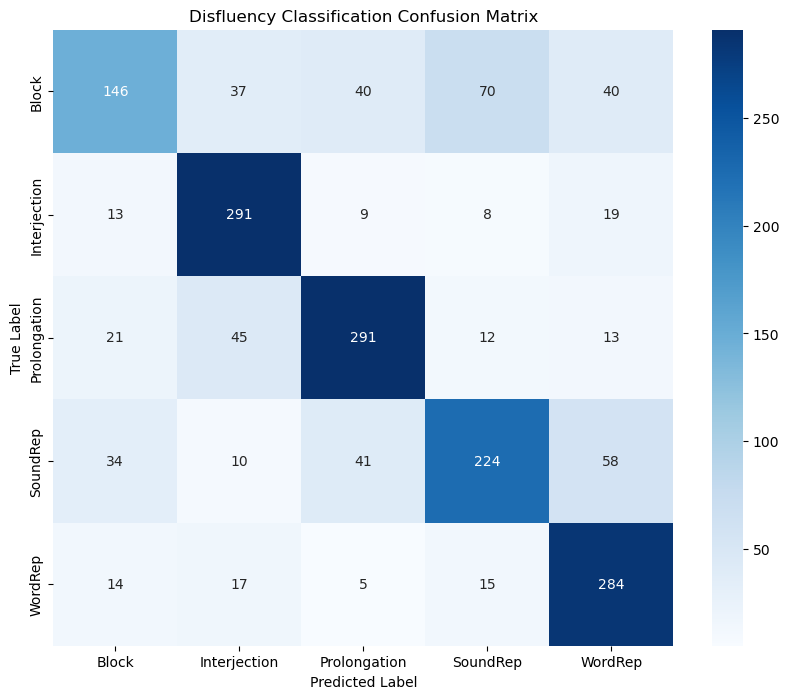


Detailed Classification Report:
              precision    recall  f1-score   support

       Block       0.64      0.44      0.52       333
Interjection       0.73      0.86      0.79       340
Prolongation       0.75      0.76      0.76       382
    SoundRep       0.68      0.61      0.64       367
     WordRep       0.69      0.85      0.76       335

    accuracy                           0.70      1757
   macro avg       0.70      0.70      0.69      1757
weighted avg       0.70      0.70      0.69      1757



In [8]:
cm = confusion_matrix(all_labels, all_preds)

class_names = label_encoder.classes_

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Disfluency Classification Confusion Matrix')
plt.show()

# (Precision, Recall, F1)
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))